# Customer Segmentation and Churn Prediction Using Machine Learning

## 1. Introduction and Problem Formulation

In the telecommunications sector, acquiring a new customer is significantly more expensive than retaining an existing one. Therefore, the metric of identifying customers who are likely to cancel their service, known as **Customer Churn**, is a critical, high-value business problem.

While traditional analytics can show *how many* people left, Machine Learning allows us to predict *who* will leave and *why*. 

### Project Objectives and Scope
This technical report explores customer retention through a two-step machine learning pipeline:
1. **Unsupervised Learning (Clustering):** Before predicting churn, we will use K-Means clustering to discover hidden segments within the customer base based on their usage patterns and demographics.
2. **Supervised Learning (Classification):** We will engineer features and train classification models (Logistic Regression and Random Forest) to predict the binary target variable (`Churn`). 

By combining these methods, we can flag high-risk customers and also understand which specific customer segment they belong to, allowing the business to tailor its retention strategies effectively.

## 2. Data Ingestion and Initial Inspection

The foundation of any robust machine learning pipeline is a thorough understanding of the raw data. We are utilizing the **Telco Customer Churn** dataset, which includes customer demographics (e.g., gender, senior citizen status), account information (e.g., tenure, contract type, payment method), and our target variable (`Churn`).

First, we will load the dataset and inspect its structure, data types, and check for any immediate data quality issues such as missing values.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Set visual style for the entire notebook
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('../data/telco_churn.csv')

print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.\n")

print("--- Data Types and Missing Values ---")
df.info()

print("\n--- First 3 Rows ---")
display(df.head(3))

Dataset Shape: 7043 rows and 21 columns.

--- Data Types and Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 3. Exploratory Data Analysis (EDA)

Before engineering features for our models, we must understand the underlying distributions and relationships within our data. We will focus on three key areas:
1. **Target Variable Distribution:** Understanding the class balance of our `Churn` column.
2. **Numeric Feature Analysis:** How does customer `tenure` (months with the company) and `MonthlyCharges` affect churn?
3. **Categorical Feature Analysis:** Does the type of `Contract` (Month-to-month vs. Two year) influence retention?

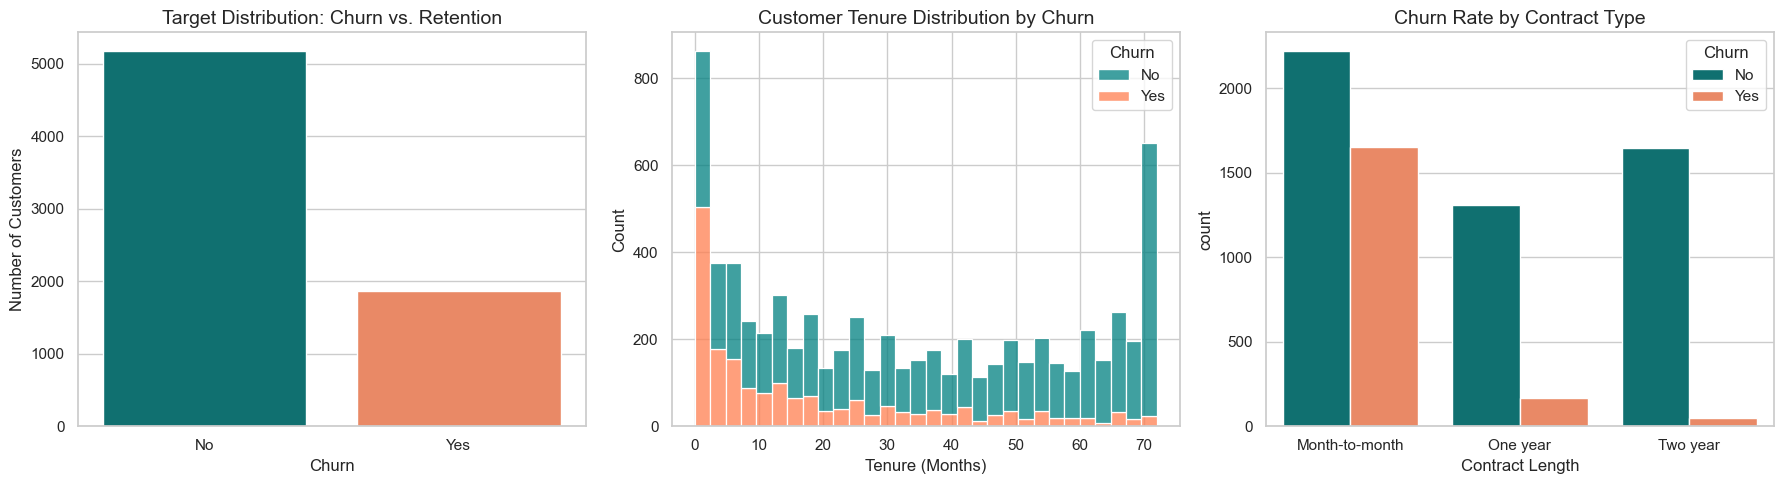

In [19]:
# Create a figure with 3 subplots for a professional layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Target Variable Distribution (Class Imbalance)
sns.countplot(data=df, x='Churn', hue='Churn', ax=axes[0], palette=['teal', 'coral'])
axes[0].set_title('Target Distribution: Churn vs. Retention', fontsize=14)
axes[0].set_ylabel('Number of Customers')

# Plot 2: Numeric Feature - Tenure vs. Churn
sns.histplot(data=df, x='tenure', hue='Churn', multiple="stack", bins=30, ax=axes[1], palette=['teal', 'coral'])
axes[1].set_title('Customer Tenure Distribution by Churn', fontsize=14)
axes[1].set_xlabel('Tenure (Months)')

# Plot 3: Categorical Feature - Contract Type vs. Churn
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[2], palette=['teal', 'coral'])
axes[2].set_title('Churn Rate by Contract Type', fontsize=14)
axes[2].set_xlabel('Contract Length')

plt.tight_layout()
plt.show()

## 4. Feature Engineering and Data Preprocessing

Before feeding this data into our machine learning algorithms, we must transform it into a mathematically digestible format. This involves several critical steps:

1. **Handling Hidden Missing Values:** The `TotalCharges` column is stored as an object (string) because new customers with zero tenure have blank spaces instead of numbers. We must convert this to numeric and handle the missing values.
2. **Dropping Identifiers:** Columns like `customerID` hold no predictive power and will confuse the model.
3. **Categorical Encoding:** Algorithms require numerical input. We will convert binary categories (Yes/No) to 0s and 1s, and use One-Hot Encoding for multi-class categories (like `PaymentMethod`).
4. **Feature Scaling:** Because K-Means clustering relies on Euclidean distance, features with larger magnitudes (like `TotalCharges`) will disproportionately dominate the algorithm. We will apply a `StandardScaler` to normalize our numeric features.

In [20]:
# 1. Fix the 'TotalCharges' column
# coerce turns blank spaces into NaNs, which we then drop (only ~11 rows lost out of 7000+)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# 2. Drop the customerID column
df.drop(columns=['customerID'], inplace=True)

# 3. Encode Binary Variables (including our target 'Churn')
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    if col == 'gender':
        df[col] = df[col].map({'Male': 1, 'Female': 0})
    else:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

# 4. One-Hot Encode the remaining multi-class categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# 5. Scale the Numerical Features
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# We create a copy to keep the scaled data separate just in case we need the original numbers later
df_scaled = df_encoded.copy()
df_scaled[num_cols] = scaler.fit_transform(df_scaled[num_cols])

print(f"Original Data Shape: {df.shape}")
print(f"Encoded & Scaled Data Shape: {df_scaled.shape}")
print("\n--- First 3 Rows of Machine-Learning-Ready Data ---")
display(df_scaled.head(3))

Original Data Shape: (7032, 20)
Encoded & Scaled Data Shape: (7032, 31)

--- First 3 Rows of Machine-Learning-Ready Data ---


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.280248,0,1,-1.161694,-0.994194,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,0.064303,1,0,-0.260878,-0.173740,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,-1.239504,1,1,-0.363923,-0.959649,1,...,False,False,False,False,False,False,False,False,False,True


## 5. Unsupervised Learning: Customer Segmentation

Before predicting churn, we want to understand the natural groupings within our customer base. We will use **K-Means Clustering**, an unsupervised machine learning algorithm that partitions the data into $k$ distinct clusters. 

The algorithm works by minimizing the **Within-Cluster Sum of Squares (WCSS)**, which is the sum of the squared Euclidean distances between each data point ($x_i$) and its assigned cluster centroid ($c_j$):

$$WCSS = \sum_{j=1}^{k} \sum_{i \in Cluster_j} ||x_i - c_j||^2$$

To determine the optimal number of clusters ($k$), we will use the **Elbow Method**, plotting the WCSS for various values of $k$ and looking for the "elbow" where the rate of decrease sharply shifts.

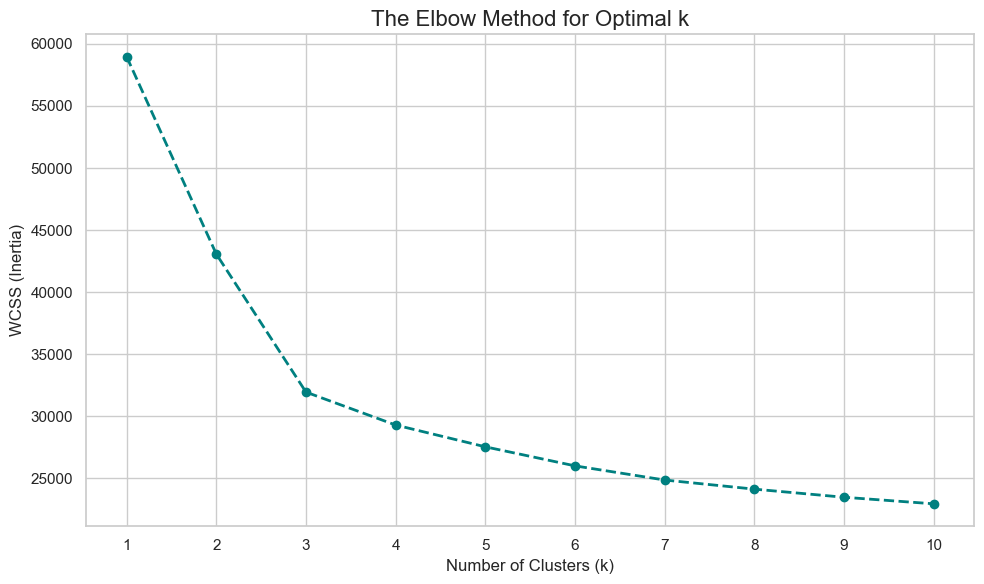

In [21]:
# Calculate WCSS for different values of k (1 through 10)
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='teal', linewidth=2)
plt.title('The Elbow Method for Optimal k', fontsize=16)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(k_range)
plt.tight_layout()
plt.show()